# Mapper v5

## Librerías

In [1]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots



#### Funciones de docs en repositorio

from Funciones import calculate_metrics


## Recolección de datos

### Sacar tickers S&P500

In [25]:
START_DATE

'2024-10-08'

In [26]:
AN_DATE

'2025-07-08'

In [27]:
END_DATE

'2025-10-08'

In [ ]:

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 503 tickers
First 10 tickers: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META', 'AVGO', 'GOOGL', 'GOOG', 'TSLA', 'BRK.B']
Found 503 weights
First 10 weights: ['8.15%', '6.43%', '6.39%', '3.93%', '3.01%', '2.89%', '2.71%', '2.54%', '2.45%', '1.65%']
Tickers after replacement: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META', 'AVGO', 'GOOGL', 'GOOG', 'TSLA', 'BRK-B']


### Información financiera

In [3]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

print("🔍 Recopilando información detallada de todos los tickers del S&P 500...")
print("=" * 80)

ticker_info_db = {}
failed_tickers = []


for idx, ticker in enumerate(tickers, 1):
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        # Extraer información relevante
        ticker_info_db[ticker] = {
            # Información básica
            'sector': info.get('sector', 'Unknown'),
            'industry': info.get('industry', 'Unknown'),
            'market_cap': info.get('marketCap', None),
            'country': info.get('country', 'Unknown'),
            'full_name': info.get('longName', ticker),
            
            # Métricas de valoración
            'pe_ratio': info.get('trailingPE', None),
            'forward_pe': info.get('forwardPE', None),
            'peg_ratio': info.get('pegRatio', None),
            'price_to_book': info.get('priceToBook', None),
            'price_to_sales': info.get('priceToSalesTrailing12Months', None),
            'enterprise_value': info.get('enterpriseValue', None),
            'ev_to_ebitda': info.get('enterpriseToEbitda', None),
            
            # Dividendos
            'dividend_yield': info.get('dividendYield', None),
            'dividend_rate': info.get('dividendRate', None),
            'payout_ratio': info.get('payoutRatio', None),
            'five_year_avg_dividend_yield': info.get('fiveYearAvgDividendYield', None),
            
            # Rentabilidad
            'profit_margins': info.get('profitMargins', None),
            'operating_margins': info.get('operatingMargins', None),
            'gross_margins': info.get('grossMargins', None),
            'roe': info.get('returnOnEquity', None),
            'roa': info.get('returnOnAssets', None),
            
            # Crecimiento
            'revenue_growth': info.get('revenueGrowth', None),
            'earnings_growth': info.get('earningsGrowth', None),
            'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
            
            # Riesgo y volatilidad
            'beta': info.get('beta', None),
            '52week_high': info.get('fiftyTwoWeekHigh', None),
            '52week_low': info.get('fiftyTwoWeekLow', None),
            '52week_change': info.get('52WeekChange', None),
            
            # Liquidez y deuda
            'current_ratio': info.get('currentRatio', None),
            'quick_ratio': info.get('quickRatio', None),
            'debt_to_equity': info.get('debtToEquity', None),
            'total_debt': info.get('totalDebt', None),
            'total_cash': info.get('totalCash', None),
            
            # Analistas y recomendaciones
            'recommendation': info.get('recommendationKey', 'Unknown'),
            'recommendation_mean': info.get('recommendationMean', None),
            'target_mean_price': info.get('targetMeanPrice', None),
            'target_high_price': info.get('targetHighPrice', None),
            'target_low_price': info.get('targetLowPrice', None),
            'number_of_analysts': info.get('numberOfAnalystOpinions', None),
            
            # Información adicional
            'employees': info.get('fullTimeEmployees', None),
            'exchange': info.get('exchange', 'Unknown'),
            'quote_type': info.get('quoteType', 'Unknown'),
        }
        
        
    except Exception as e:
        failed_tickers.append(ticker)
        ticker_info_db[ticker] = {
            'sector': 'Unknown',
            'industry': 'Unknown',
            'error': str(e)
        }

print(f"\n{'='*80}")
print(f"📊 RESUMEN DE RECOPILACIÓN:")
if failed_tickers:
    print(f"   Tickers fallidos: {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")

# Crear DataFrame para análisis fácil
ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')

print(f"\n DataFrame de información creado: {ticker_info_df.shape}")


# Guardar en CSV para uso posterior
ticker_info_df.to_csv('sp500_ticker_info_database.csv')
print("\n Base de datos guardada en 'sp500_ticker_info_database.csv'")

# Mostrar primeras filas
print("\n Primeras filas de la base de datos:")
display(ticker_info_df.head(10))

🔍 Recopilando información detallada de todos los tickers del S&P 500...

📊 RESUMEN DE RECOPILACIÓN:

 DataFrame de información creado: (503, 42)

 Base de datos guardada en 'sp500_ticker_info_database.csv'

 Primeras filas de la base de datos:

📊 RESUMEN DE RECOPILACIÓN:

 DataFrame de información creado: (503, 42)

 Base de datos guardada en 'sp500_ticker_info_database.csv'

 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name,pe_ratio,forward_pe,peg_ratio,price_to_book,price_to_sales,...,total_cash,recommendation,recommendation_mean,target_mean_price,target_high_price,target_low_price,number_of_analysts,employees,exchange,quote_type
NVDA,Technology,Semiconductors,5081706004480,United States,NVIDIA Corporation,59.295456,50.660194,None,50.746414,30.759054,...,5.679100e+10,strong_buy,1.34375,222.82947,320.0,100.0,57.0,36000.0,NMS,EQUITY
MSFT,Technology,Software - Infrastructure,4007697580032,United States,Microsoft Corporation,39.470720,36.064880,None,11.669336,14.225616,...,9.456500e+10,strong_buy,1.22807,621.06885,730.0,483.0,52.0,228000.0,NMS,EQUITY
AAPL,Technology,Consumer Electronics,3987612893184,United States,Apple Inc.,40.773900,32.334538,None,60.640938,9.758613,...,5.537200e+10,buy,2.04167,256.00660,320.0,180.0,41.0,150000.0,NMS,EQUITY
AMZN,Consumer Cyclical,Internet Retail,2453143027712,United States,"Amazon.com, Inc.",35.064026,37.401627,None,7.346300,3.661200,...,9.318000e+10,strong_buy,1.28986,267.92062,306.0,230.0,63.0,1546000.0,NMS,EQUITY
META,Communication Services,Internet Content & Information,1878730211328,United States,"Meta Platforms, Inc.",27.116026,29.559685,None,9.645824,10.507205,...,4.707100e+10,strong_buy,1.41176,868.30530,1086.0,616.0,62.0,75945.0,NMS,EQUITY
AVGO,Technology,Semiconductors,1799231373312,United States,Broadcom Inc.,97.194435,61.750760,None,6.433566,30.024220,...,1.110500e+10,strong_buy,1.28261,392.38165,475.0,273.4,41.0,37000.0,NMS,EQUITY
GOOGL,Communication Services,Internet Content & Information,3277304365056,United States,Alphabet Inc.,28.812565,30.195310,None,9.023446,8.824214,...,9.514800e+10,buy,1.50746,263.15076,340.0,185.0,52.0,187103.0,NMS,EQUITY
GOOG,Communication Services,Internet Content & Information,3275782881280,United States,Alphabet Inc.,28.964247,30.323463,None,9.051629,8.820118,...,9.514800e+10,strong_buy,1.50000,267.39413,310.0,185.0,17.0,187103.0,NMS,EQUITY
TSLA,Consumer Cyclical,Auto Manufacturers,1528114184192,United States,"Tesla, Inc.",321.307700,141.811720,None,19.098429,15.978943,...,4.164700e+10,hold,2.56522,395.52600,600.0,120.0,40.0,125665.0,NMS,EQUITY
BRK-B,Financial Services,Insurance - Diversified,1030040911872,United States,Berkshire Hathaway Inc.,16.359835,23.773905,None,0.001028,2.782759,...,3.440910e+11,buy,2.00000,519.66670,593.0,479.0,3.0,392400.0,NYQ,EQUITY


### Datos históricos

In [4]:
# -----------------------------
# Descargar precios históricos
# -----------------------------
all_tickers_data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
all_tickers_data = all_tickers_data.dropna(axis=1)  # eliminar columnas con datos faltantes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

[*********************100%***********************]  503 of 503 completed



✅ Datos descargados:
   📊 Total: (250, 503) (desde 2024-10-08 hasta 2025-10-08)
   📊 Período de análisis: (186, 503) (desde 2024-10-08 hasta 2025-07-08)
   📊 Período de validación: (65, 503) (desde 2025-07-08 hasta 2025-10-08)


In [5]:
# Descargar SPY para benchmark
SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Verificar si es Serie o DataFrame y convertir apropiadamente
if isinstance(SPY_data, pd.Series):
    SPY = SPY_data.to_frame(name='SPY')
else:
    # Si ya es DataFrame, asegurarse que la columna se llame 'SPY'
    SPY = SPY_data.to_frame() if len(SPY_data.shape) == 1 else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY descargado:")
print(f"   📊 SPY_analysis: {SPY_analysis.shape}")
print(f"   📊 SPY_validation: {SPY_validation.shape}")
print(f"   📋 Columnas: {SPY_analysis.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

✅ SPY descargado:
   📊 SPY_analysis: (186, 1)
   📊 SPY_validation: (65, 1)
   📋 Columnas: ['SPY']


### Análisis inicial

In [6]:
# =======================================================
# 📈 ESTADÍSTICAS GENERALES DE LA BASE DE DATOS
# =======================================================

print("\n📈 ESTADÍSTICAS GENERALES DEL S&P 500:")
print("=" * 80)

# Distribución por Sector
print("\n🏢 DISTRIBUCIÓN POR SECTOR:")
sector_counts = ticker_info_df['sector'].value_counts()
for sector, count in sector_counts.items():
    pct = (count / len(ticker_info_df)) * 100
    print(f"   {sector:30s}: {count:3d} empresas ({pct:5.1f}%)")

# Top 10 Industrias
print("\n🏭 TOP 10 INDUSTRIAS:")
industry_counts = ticker_info_df['industry'].value_counts().head(10)
for industry, count in industry_counts.items():
    print(f"   {industry:50s}: {count:2d} empresas")

# Distribución por País
print("\n🌍 TOP 10 PAÍSES:")
country_counts = ticker_info_df['country'].value_counts().head(10)
for country, count in country_counts.items():
    pct = (count / len(ticker_info_df)) * 100
    print(f"   {country:30s}: {count:3d} empresas ({pct:5.1f}%)")

# Estadísticas de métricas financieras
print("\n💰 ESTADÍSTICAS DE MÉTRICAS FINANCIERAS (Medianas):")
financial_stats = {
    'Market Cap (Billones)': ticker_info_df['market_cap'].median() / 1e9 if ticker_info_df['market_cap'].notna().any() else None,
    'P/E Ratio': ticker_info_df['pe_ratio'].median(),
    'Beta': ticker_info_df['beta'].median(),
    'ROE (%)': ticker_info_df['roe'].median() * 100 if ticker_info_df['roe'].notna().any() else None,
    'Profit Margin (%)': ticker_info_df['profit_margins'].median() * 100 if ticker_info_df['profit_margins'].notna().any() else None,
    'Debt/Equity': ticker_info_df['debt_to_equity'].median(),
    'Dividend Yield (%)': ticker_info_df['dividend_yield'].median() * 100 if ticker_info_df['dividend_yield'].notna().any() else None,
}

for metric, value in financial_stats.items():
    if value is not None and not np.isnan(value):
        print(f"   {metric:25s}: {value:8.2f}")

# Empresas más grandes por Market Cap
print("\n🏆 TOP 10 EMPRESAS POR MARKET CAP:")
top_companies = ticker_info_df.nlargest(10, 'market_cap')[['full_name', 'sector', 'market_cap']]
for idx, (ticker, row) in enumerate(top_companies.iterrows(), 1):
    market_cap_b = row['market_cap'] / 1e9 if pd.notna(row['market_cap']) else 0
    print(f"   {idx:2d}. {ticker:5s} - {row['full_name'][:40]:40s} | ${market_cap_b:6.1f}B | {row['sector']}")

print(f"\n{'='*80}")
print("✅ Estadísticas generales completadas")


📈 ESTADÍSTICAS GENERALES DEL S&P 500:

🏢 DISTRIBUCIÓN POR SECTOR:
   Technology                    :  81 empresas ( 16.1%)
   Industrials                   :  72 empresas ( 14.3%)
   Financial Services            :  69 empresas ( 13.7%)
   Healthcare                    :  60 empresas ( 11.9%)
   Consumer Cyclical             :  55 empresas ( 10.9%)
   Consumer Defensive            :  37 empresas (  7.4%)
   Real Estate                   :  31 empresas (  6.2%)
   Utilities                     :  31 empresas (  6.2%)
   Communication Services        :  25 empresas (  5.0%)
   Energy                        :  22 empresas (  4.4%)
   Basic Materials               :  20 empresas (  4.0%)

🏭 TOP 10 INDUSTRIAS:
   Utilities - Regulated Electric                    : 23 empresas
   Software - Application                            : 17 empresas
   Specialty Industrial Machinery                    : 17 empresas
   Software - Infrastructure                         : 15 empresas
   Semiconductor

In [7]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T
ticker_names = metrics_df.index.tolist()


🔄 Calculando métricas financieras...


## Creación mapper

In [8]:
# =======================================================
# CREAR SUBCARPETA PARA VISUALIZACIONES
# =======================================================

import os

# Crear la subcarpeta para todas las visualizaciones
output_folder = 'portafolio_v5_visualizaciones'
os.makedirs(output_folder, exist_ok=True)
print(f"📁 Subcarpeta creada: {output_folder}/")
print(f"🌐 Todas las visualizaciones HTML se guardarán en esta carpeta")

📁 Subcarpeta creada: portafolio_v5_visualizaciones/
🌐 Todas las visualizaciones HTML se guardarán en esta carpeta


### Configuración inicial mapper

In [9]:

# Escalamos
data = StandardScaler().fit_transform(tickers_data)

# Inicializamos Mapper
mapper = km.KeplerMapper(verbose=1)  # verbose=1 para ver debug info


KeplerMapper(verbose=1)


### Configuraciones varias

In [10]:

# Proyección (lens): PCA a 2D
lens = mapper.fit_transform(data, projection=PCA(n_components=2))

# Construcción del grafo con KMeans
graph_1 = mapper.map(
    lens, 
    data, 
    clusterer=KMeans(n_clusters=3, random_state=0),  # ✅ KMeans más confiable
    cover=km.Cover(n_cubes=10, perc_overlap=0.5)
)

print(f"✅ Nodos encontrados: {len(graph_1['nodes'])}")
print(f"✅ Aristas encontradas: {len(graph_1['links'])}")

# Visualización interactiva
mapper.visualize(graph_1, 
                 title="Mapper de series de tiempo",
                 custom_tooltips=np.array(ticker_names),  # Mostrar nombres de tickers
                 path_html="portafolio_v5_visualizaciones/mapper_output.html")

..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (186, 503)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()

Mapping on data shaped (186, 503) using lens shaped (186, 2)

Creating 100 hypercubes.

Created 353 edges and 162 nodes in 0:00:01.534397.
✅ Nodos encontrados: 162
✅ Aristas encontradas: 128
Wrote visualization to: portafolio_v5_visualizaciones/mapper_output.html

Created 353 edges and 162 nodes in 0:00:01.534397.
✅ Nodos encontrados: 162
✅ Aristas encontradas: 128
Wrote visualization to: portafolio_v5_visualizaciones/mapper_output.html


'<!DOCTYPE html>\n<html>\n\n<head>\n  <meta charset="utf-8">\n  <meta name="generator" content="KeplerMapper">\n  <title>Mapper de series de tiempo | KeplerMapper</title>\n\n  <link rel="icon" type="image/png" href="http://i.imgur.com/axOG6GJ.jpg" />\n\n  <link href=\'https://fonts.googleapis.com/css?family=Roboto+Mono:700,300\' rel=\'stylesheet\' type=\'text/css\'>\n  <style>* {\n  margin: 0;\n  padding: 0;\n}\n\nhtml, body {\n  height: 100%;\n}\n\nbody {\n  font-family: "Roboto Mono", "Helvetica", sans-serif;\n  font-size: 14px;\n}\n\n#logo {\n  width:  85px;\n  height: 85px;\n}\n\n#display {\n  color: #95A5A6;\n  background: #212121;\n}\n\n#header {\n  background: #111111;\n}\n\n#print {\n  color: #000;\n  background: #FFF;\n}\n\nh1 {\n  font-size: 21px;\n  font-weight: 300;\n  font-weight: 300;\n}\n\nh2 {\n  font-size: 18px;\n  padding-bottom: 20px;\n  font-weight: 300;\n}\n\nh3 {\n  font-size: 14px;\n  font-weight: 700;\n  text-transform: uppercase;\n}\n\nh4 {\n  font-size: 13px;\

## Análisis resultados

### Extraer clusters

In [11]:
all_clusters = {}


# 1. Extraer clusters del grafo G (Sharpe Ratio)
print(f"\n Extrayendo clusters del análisis por Sharpe Ratio (G):")
print(f"Total de nodos: {len(graph_1['nodes'])}")
for i, (node_name, node_indices) in enumerate(graph_1['nodes'].items()):
    if len(node_indices) >= 4:  # Solo clusters con al menos 4 tickers
        cluster_tickers = [ticker_names[idx] for idx in node_indices]
        cluster_name = f"Config1_{i+1}"
        all_clusters[cluster_name] = {
            'tickers': cluster_tickers,
            'type': 'Sharpe Ratio',
            'node_name': node_name,
            'size': len(cluster_tickers)
        }
        print(f"     {cluster_name}: {cluster_tickers} ({len(cluster_tickers)} tickers)")


 Extrayendo clusters del análisis por Sharpe Ratio (G):
Total de nodos: 162
     Config1_4: ['DAY', 'DD', 'DDOG', 'DE', 'DECK'] (5 tickers)
     Config1_7: ['DAY', 'DD', 'DDOG', 'DE', 'DECK'] (5 tickers)
     Config1_10: ['DHR', 'DIS', 'DLR', 'DLTR'] (4 tickers)
     Config1_14: ['DOW', 'DPZ', 'DRI', 'DTE'] (4 tickers)
     Config1_15: ['DHR', 'DIS', 'DLR', 'DLTR'] (4 tickers)
     Config1_19: ['DAY', 'DD', 'DDOG', 'DE'] (4 tickers)
     Config1_22: ['CVS', 'DAY', 'DD', 'DDOG', 'DE'] (5 tickers)
     Config1_25: ['DHR', 'DIS', 'DLR', 'DLTR', 'DOC', 'DOV'] (6 tickers)
     Config1_29: ['DOW', 'DPZ', 'DRI', 'DTE'] (4 tickers)
     Config1_30: ['DHR', 'DIS', 'DLR', 'DLTR'] (4 tickers)
     Config1_34: ['EL', 'ELV', 'EME', 'EMN', 'EMR', 'EOG'] (6 tickers)
     Config1_35: ['DUK', 'DVA', 'EFX', 'EG', 'EIX'] (5 tickers)
     Config1_37: ['EPAM', 'EQIX', 'EQR', 'EQT', 'ERIE', 'ETN'] (6 tickers)
     Config1_38: ['ETR', 'EVRG', 'EW', 'EXC', 'EXE', 'EXPD', 'EXR'] (7 tickers)
     Config1_39: [

In [12]:
categories = {ticker: ticker_info_db[ticker]['sector'] for ticker in ticker_names}
market_caps = {ticker: ticker_info_db[ticker]['market_cap'] for ticker in ticker_names}

### Crear portafolios

In [13]:
def create_market_cap_weighted_index(cluster_tickers, data, market_caps_dict, start_value=1):
    """
    Crea un índice ponderado por capitalización de mercado para un cluster específico.
    
    Parámetros:
    -----------
    cluster_tickers : list
        Lista de tickers del cluster
    data : pd.DataFrame
        DataFrame con precios históricos (tickers como columnas)
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1)
    
    Retorna:
    --------
    index_series : pd.Series
        Serie temporal del índice
    weights : dict
        Diccionario con los pesos de cada ticker
    """
    # Filtrar tickers que existen tanto en data como en market_caps
    valid_tickers = [t for t in cluster_tickers if t in data.columns and t in market_caps_dict]
    
    if not valid_tickers:
        print(f"⚠️  No hay tickers válidos en el cluster")
        return None, None
    
    # Calcular capitalización total del cluster
    total_market_cap = sum([market_caps_dict[ticker] for ticker in valid_tickers])
    
    # Calcular pesos de cada ticker (capitalización / capitalización total)
    weights = {ticker: market_caps_dict[ticker] / total_market_cap for ticker in valid_tickers}
    
    # Crear el índice
    index_series = pd.Series(0, index=data.index)
    
    for ticker, weight in weights.items():
        # Normalizar precios del ticker al valor inicial
        ticker_prices = data[ticker].dropna()
        if len(ticker_prices) > 0:
            ticker_normalized = (ticker_prices / ticker_prices.iloc[0]) * start_value
            # Agregar al índice con su peso
            index_series = index_series.add(ticker_normalized * weight, fill_value=0)
    
    return index_series, weights

In [14]:
def create_all_cluster_indices(all_clusters, data, market_caps_dict, start_value=1):
    """
    Crea índices ponderados por capitalización para todos los clusters.
    
    Parámetros:
    -----------
    all_clusters : dict
        Diccionario con todos los clusters {cluster_name: {tickers: [...], ...}}
    data : pd.DataFrame
        DataFrame con precios históricos
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1)
    
    Retorna:
    --------
    cluster_indices : dict
        Diccionario con {cluster_name: {index: serie, weights: dict, metrics: dict}}
    """
    cluster_indices = {}
    
    for cluster_name, cluster_info in all_clusters.items():
        cluster_tickers = cluster_info['tickers']
        cluster_type = cluster_info['type']
        
        # Crear índice para este cluster
        index_series, weights = create_market_cap_weighted_index(
            cluster_tickers, data, market_caps_dict, start_value
        )
        
        # ✅ Verificar que se creó correctamente el índice
        if index_series is None or weights is None:
            print(f"⚠️ No se pudo crear índice para {cluster_name}")
            continue
        
        # ✅ Calcular métricas del índice (DENTRO del loop)
        returns = index_series.pct_change().dropna()

        total_return = (index_series.iloc[-1] / index_series.iloc[0] - 1) * 100  # En porcentaje
        volatility = returns.std() * np.sqrt(252) * 100  # En porcentaje
        sharpe = (returns.mean() / returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        max_drawdown = ((index_series / index_series.cummax()) - 1).min() * 100  # En porcentaje

        metrics = {
            'retorno_total': total_return,
            'volatilidad': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'valor_final': index_series.iloc[-1],
            'num_tickers': len(weights)
        }

        # ✅ Guardar el índice en el diccionario (DENTRO del loop)
        cluster_indices[cluster_name] = {
            'index': index_series,
            'weights': weights,
            'metrics': metrics,
            'type': cluster_type
        }
        
        print(f"✅ {cluster_name}: {len(weights)} tickers, Sharpe={sharpe:.2f}, Ret={total_return:.2f}%")
    
    return cluster_indices

In [15]:
def plot_top_clusters_same_period(cluster_indices_dict, top_clusters_list, data_for_spy, 
                                  period_name, ranking_metric, figsize=(16, 8)):
    """
    Grafica los top clusters usando los mismos datos con los que fueron creados.
    
    Parámetros:
    -----------
    cluster_indices_dict : dict
        Diccionario con índices ya calculados {cluster_name: {index: serie, metrics: dict}}
    top_clusters_list : list
        Lista de nombres de clusters a graficar (top N)
    data_for_spy : pd.DataFrame
        DataFrame con datos para el benchmark SPY
    period_name : str
        Nombre del período ("Análisis" o "Validación")
    ranking_metric : str
        Métrica usada para ranking ("Sharpe Ratio" o "Score")
    figsize : tuple
        Tamaño de la figura (default: (16, 8))
    """
    print(f"\n📈 Graficando Top {len(top_clusters_list)} clusters por {ranking_metric} (Período de {period_name})...")
    
    plt.figure(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_clusters_list)))
    
    for i, cluster_name in enumerate(top_clusters_list):
        if cluster_name in cluster_indices_dict:
            cluster_data = cluster_indices_dict[cluster_name]
            index_series = cluster_data['index']
            metrics = cluster_data['metrics']
            
            # Construir label según métrica
            if ranking_metric == "Sharpe Ratio":
                label = f"{cluster_name} (Sh={metrics['sharpe_ratio']:.2f}, Ret={metrics['retorno_total']:.1f}%)"
            elif ranking_metric == "Score":
                label = f"{cluster_name} (Score={metrics.get('score', 0):.2f}, Sh={metrics['sharpe_ratio']:.2f})"
            else:
                label = f"{cluster_name}"
            
            plt.plot(index_series, label=label, linewidth=2.5, alpha=0.8, color=colors[i])
    
    # Agregar benchmark SPY
    spy_series = data_for_spy['SPY'].dropna()
    spy_normalized = spy_series / spy_series.iloc[0]
        
    plt.plot(spy_normalized, linewidth=3, linestyle='--', color='black', alpha=0.7, label='SPY (Benchmark)')
    plt.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    plt.title(f'📊 Top {len(top_clusters_list)} Índices por {ranking_metric}\n(Período de {period_name})', 
             fontsize=16, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Valor del Índice (Base 1.0)', fontsize=12)
    plt.legend(fontsize=9, loc='upper left', ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Gráfica generada")


def plot_top_clusters_cross_period(top_clusters_list, all_clusters, target_data, target_data_spy,
                                   source_summary_df, market_caps_dict, 
                                   source_period_name, target_period_name, ranking_metric,
                                   weights_dict=None, figsize=(16, 8)):
    """
    Grafica los top clusters de un período usando datos de otro período (validación cruzada).
    
    Parámetros:
    -----------
    top_clusters_list : list
        Lista de nombres de clusters a graficar (top N del período fuente)
    all_clusters : dict
        Diccionario con información de todos los clusters {cluster_name: {tickers: [...], ...}}
    target_data : pd.DataFrame
        DataFrame con precios del período objetivo (donde se evaluarán)
    target_data_spy : pd.DataFrame
        DataFrame con datos SPY del período objetivo
    source_summary_df : pd.DataFrame
        DataFrame con métricas del período fuente
    market_caps_dict : dict
        Diccionario con capitalizaciones de mercado
    source_period_name : str
        Nombre del período fuente ("Análisis" o "Validación")
    target_period_name : str
        Nombre del período objetivo ("Validación" o "Análisis")
    ranking_metric : str
        Métrica usada para ranking ("Sharpe Ratio" o "Score")
    weights_dict : dict
        Diccionario con pesos para Score (W1, W2, W3, W4) si ranking_metric == "Score"
    figsize : tuple
        Tamaño de la figura (default: (16, 8))
    """
    print(f"\n🔄 Top {len(top_clusters_list)} de {source_period_name} evaluados en {target_period_name}...")
    
    # Crear índices con datos del período objetivo
    cluster_indices_cross = {}
    
    for cluster_name in top_clusters_list:
        cluster_info = all_clusters[cluster_name]
        cluster_tickers = cluster_info['tickers']
        
        # Crear índice con datos objetivo
        index_series, weights = create_market_cap_weighted_index(
            cluster_tickers, target_data, market_caps_dict, start_value=1
        )
        
        if index_series is None:
            continue
        
        # Calcular métricas en período objetivo
        returns = index_series.pct_change().dropna()
        total_return = (index_series.iloc[-1] / index_series.iloc[0] - 1) * 100
        volatility = returns.std() * np.sqrt(252) * 100
        sharpe = (returns.mean() / returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        max_drawdown = ((index_series / index_series.cummax()) - 1).min() * 100
        
        # Obtener métrica del período fuente
        source_row = source_summary_df[source_summary_df['Cluster'] == cluster_name].iloc[0]
        
        if ranking_metric == "Score" and weights_dict:
            score_target = (weights_dict['W1'] * total_return + 
                          weights_dict['W2'] * sharpe - 
                          weights_dict['W3'] * volatility - 
                          weights_dict['W4'] * abs(max_drawdown))
            score_source = source_row['Score']
            
            cluster_indices_cross[cluster_name] = {
                'index': index_series,
                'sharpe_target': sharpe,
                'retorno_target': total_return,
                'score_target': score_target,
                'score_source': score_source,
                'sharpe_source': source_row['Sharpe Ratio'],
                'retorno_source': source_row['Retorno (%)']
            }
        else:
            cluster_indices_cross[cluster_name] = {
                'index': index_series,
                'sharpe_target': sharpe,
                'retorno_target': total_return,
                'sharpe_source': source_row['Sharpe Ratio'],
                'retorno_source': source_row['Retorno (%)']
            }
    
    # Graficar
    plt.figure(figsize=figsize)
    colors = plt.cm.tab10(np.linspace(0, 1, len(top_clusters_list)))
    
    for i, cluster_name in enumerate(top_clusters_list):
        if cluster_name in cluster_indices_cross:
            data = cluster_indices_cross[cluster_name]
            index_series = data['index']
            
            # Construir label según métrica
            if ranking_metric == "Score":
                label = (f"{cluster_name} | {target_period_name}: Score={data['score_target']:.2f} | "
                        f"{source_period_name}: Score={data['score_source']:.2f}")
            else:
                label = (f"{cluster_name} | {target_period_name}: Sh={data['sharpe_target']:.2f}, Ret={data['retorno_target']:.1f}% | "
                        f"{source_period_name}: Sh={data['sharpe_source']:.2f}")
            
            plt.plot(index_series, label=label, linewidth=2.5, alpha=0.8, color=colors[i])
    
    # Agregar benchmark SPY
    
    spy_series = target_data_spy['SPY'].dropna()
    spy_normalized = spy_series / spy_series.iloc[0]
        
    plt.plot(spy_normalized, linewidth=3, linestyle='--', color='black', alpha=0.7, label='SPY (Benchmark)')
    plt.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    plt.title(f'🔄 Top {len(top_clusters_list)} de {source_period_name} evaluados en {target_period_name}\n(Ranking por {ranking_metric})', 
             fontsize=16, fontweight='bold')
    plt.xlabel('Fecha', fontsize=12)
    plt.ylabel('Valor del Índice (Base 1.0)', fontsize=12)
    plt.legend(fontsize=7.5, loc='upper left', ncol=1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Gráfica generada: Top {len(top_clusters_list)} de {source_period_name} en {target_period_name}")

In [16]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Paso 3: Crear tabla resumen con métricas
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES CREADOS")
print("=" * 100)

summary_data = []
for cluster_name, cluster_data in cluster_indices.items():
    summary_data.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'],
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Sharpe Ratio', ascending=False)

print("\n📊 TOP 10 ÍNDICES POR SHARPE RATIO:")
print(summary_df.head(10).to_string(index=False))

print("\n\n📊 ESTADÍSTICAS GENERALES:")
print(f"   📈 Retorno promedio: {summary_df['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df['Volatilidad (%)'].mean():.2f}%")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df['Sharpe Ratio'].mean():.2f}")
print(f"   📉 Max Drawdown promedio: {summary_df['Max Drawdown (%)'].mean():.2f}%")

🔍 Verificando datos necesarios...
   ✓ all_clusters: 88 clusters
   ✓ tickers_data: (186, 503)
   ✓ market_caps: 503 tickers con capitalización
✅ Config1_4: 5 tickers, Sharpe=0.85, Ret=15.66%
✅ Config1_7: 5 tickers, Sharpe=0.85, Ret=15.66%
✅ Config1_10: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_14: 4 tickers, Sharpe=0.48, Ret=5.48%
✅ Config1_15: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_19: 4 tickers, Sharpe=0.96, Ret=18.49%
✅ Config1_22: 5 tickers, Sharpe=0.84, Ret=14.23%
✅ Config1_25: 6 tickers, Sharpe=0.60, Ret=9.06%
✅ Config1_29: 4 tickers, Sharpe=0.48, Ret=5.48%
✅ Config1_30: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_34: 6 tickers, Sharpe=0.18, Ret=1.07%
✅ Config1_35: 5 tickers, Sharpe=-0.10, Ret=-2.26%
✅ Config1_37: 6 tickers, Sharpe=0.31, Ret=3.52%
✅ Config1_38: 7 tickers, Sharpe=1.12, Ret=12.47%
✅ Config1_39: 9 tickers, Sharpe=-0.03, Ret=-2.27%
✅ Config1_40: 4 tickers, Sharpe=1.30, Ret=14.88%
✅ Config1_41: 6 tickers, Sharpe=0.31, Ret=3.52%
✅ Config1_42: 4 tickers, Shar


📈 Graficando Top 10 clusters por Sharpe Ratio (Período de Análisis)...


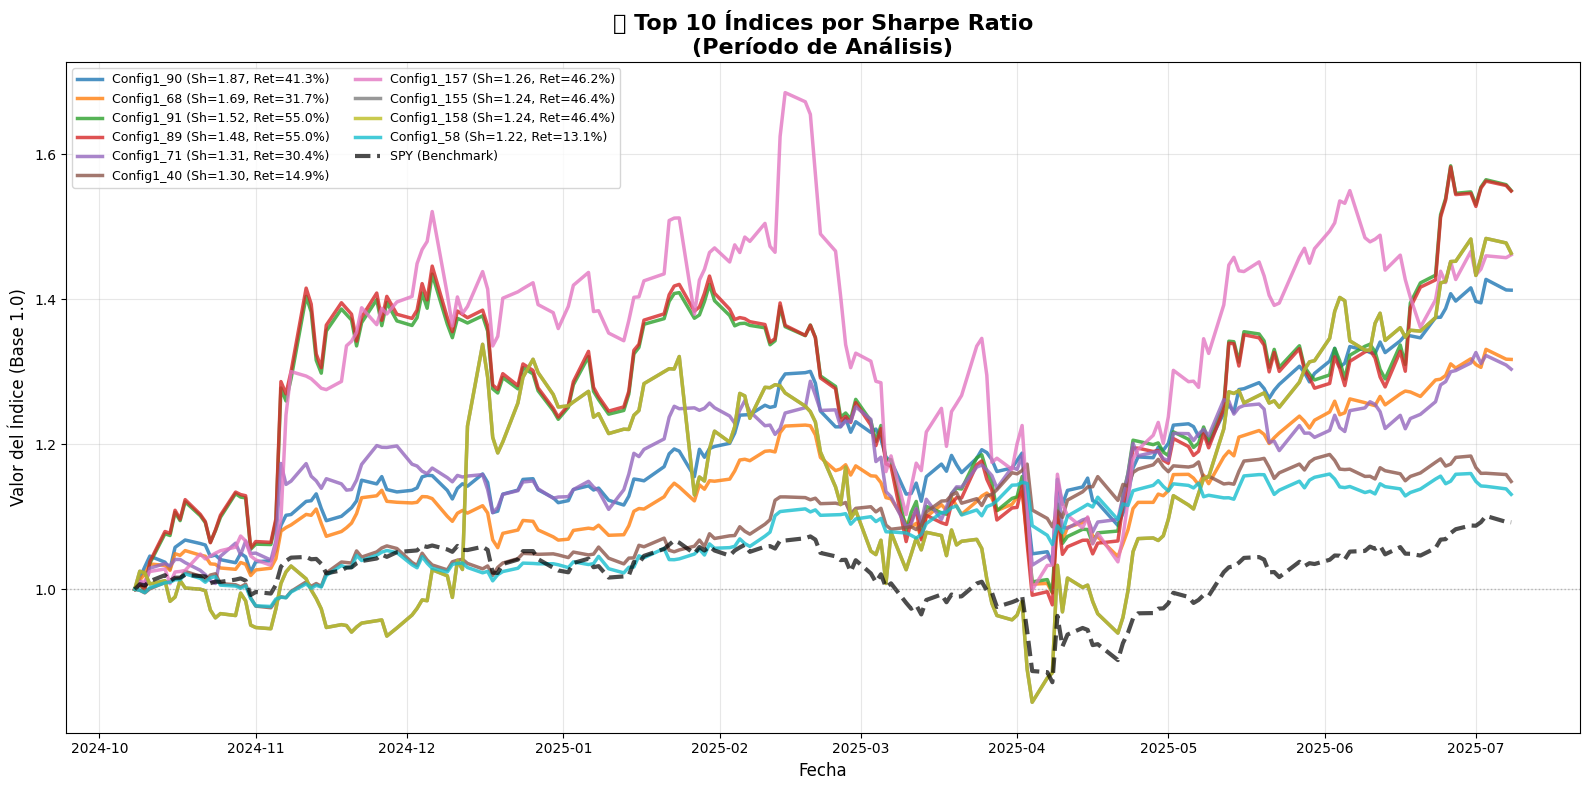

✅ Gráfica generada


In [17]:
# Visualizar los mejores 10 índices del PERÍODO DE ANÁLISIS usando función estandarizada
top_10_clusters_analysis = summary_df.head(10)['Cluster'].tolist()

plot_top_clusters_same_period(
    cluster_indices_dict=cluster_indices,
    top_clusters_list=top_10_clusters_analysis,
    data_for_spy=SPY_analysis,
    period_name="Análisis",
    ranking_metric="Sharpe Ratio"
)

🔍 Verificando datos necesarios...
   ✓ all_clusters: 88 clusters
   ✓ tickers_data: (186, 503)
   ✓ market_caps: 503 tickers con capitalización
✅ Config1_4: 5 tickers, Sharpe=-0.33, Ret=-2.05%
✅ Config1_7: 5 tickers, Sharpe=-0.33, Ret=-2.05%
✅ Config1_10: 4 tickers, Sharpe=-0.51, Ret=-2.46%
✅ Config1_14: 4 tickers, Sharpe=-1.28, Ret=-5.76%
✅ Config1_15: 4 tickers, Sharpe=-0.51, Ret=-2.46%
✅ Config1_19: 4 tickers, Sharpe=-0.26, Ret=-1.78%
✅ Config1_22: 5 tickers, Sharpe=1.10, Ret=4.01%
✅ Config1_25: 6 tickers, Sharpe=-0.59, Ret=-2.74%
✅ Config1_29: 4 tickers, Sharpe=-1.28, Ret=-5.76%
✅ Config1_30: 4 tickers, Sharpe=-0.51, Ret=-2.46%
✅ Config1_34: 6 tickers, Sharpe=0.28, Ret=0.87%
✅ Config1_35: 5 tickers, Sharpe=1.40, Ret=4.59%
✅ Config1_37: 6 tickers, Sharpe=0.60, Ret=2.08%
✅ Config1_38: 7 tickers, Sharpe=2.46, Ret=7.06%
✅ Config1_39: 9 tickers, Sharpe=0.25, Ret=0.68%
✅ Config1_40: 4 tickers, Sharpe=1.93, Ret=6.09%
✅ Config1_41: 6 tickers, Sharpe=0.60, Ret=2.08%
✅ Config1_42: 4 tickers,

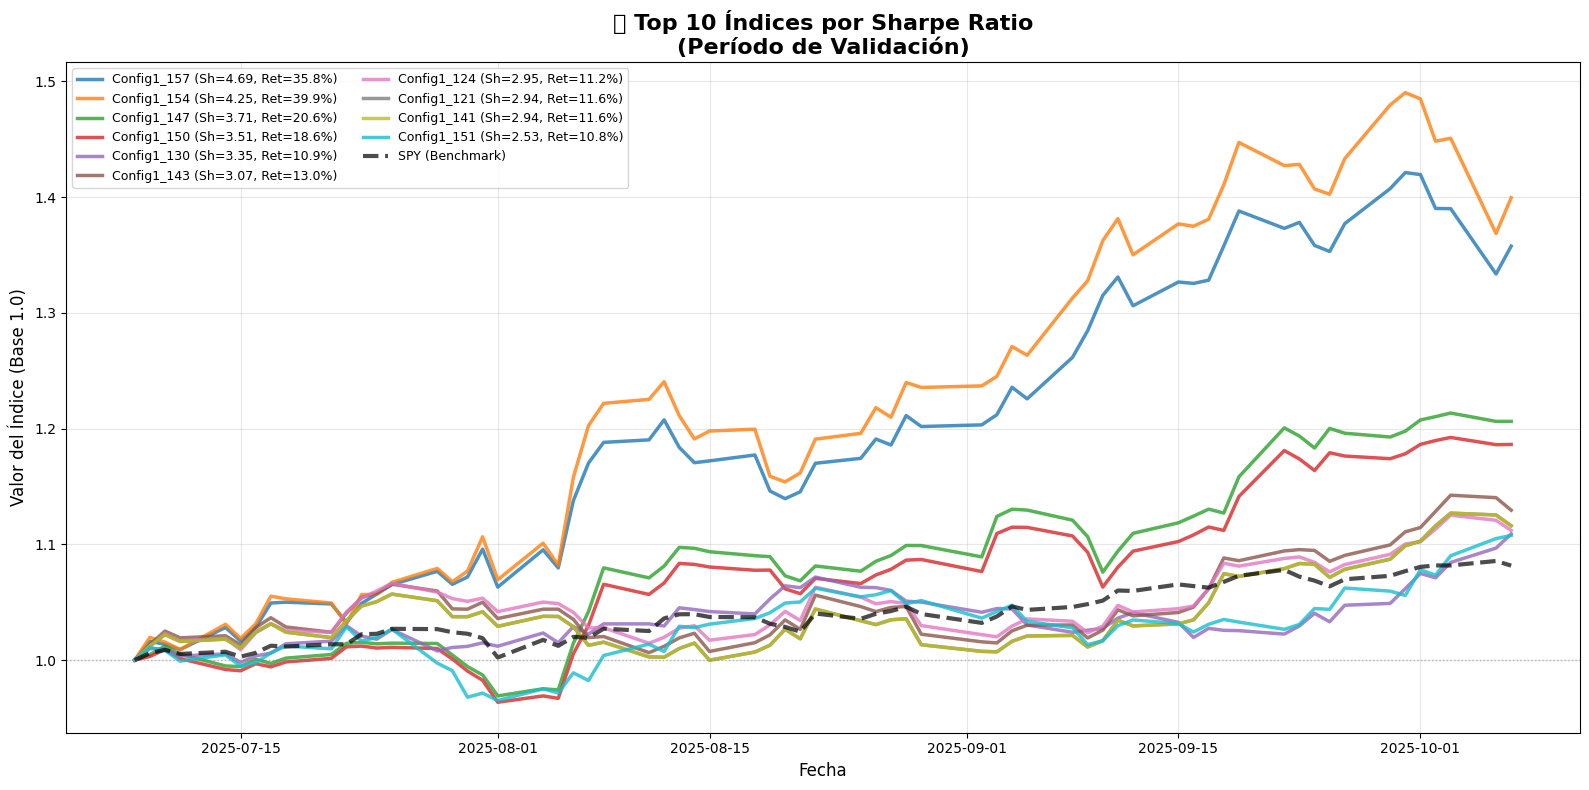

✅ Gráfica generada


In [18]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=validation_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Paso 3: Crear tabla resumen con métricas
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES CREADOS (PERÍODO DE VALIDACIÓN)")
print("=" * 100)

summary_data = []
for cluster_name, cluster_data in cluster_indices.items():
    index_series = cluster_data['index']
    summary_data.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Valor Inicial': index_series.iloc[0],  # ✅ Valor inicial
        'Valor Final': cluster_data['metrics']['valor_final'],  # ✅ Valor final
        'Retorno (%)': cluster_data['metrics']['retorno_total'],
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Sharpe Ratio', ascending=False)

print("\n📊 TOP 10 ÍNDICES POR SHARPE RATIO:")
print(summary_df.head(10).to_string(index=False))

print("\n\n📊 ESTADÍSTICAS GENERALES:")
print(f"   📈 Retorno promedio: {summary_df['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df['Volatilidad (%)'].mean():.2f}%")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df['Sharpe Ratio'].mean():.2f}")
print(f"   📉 Max Drawdown promedio: {summary_df['Max Drawdown (%)'].mean():.2f}%")

# Paso 4: Visualizar los mejores 10 índices usando función estandarizada
top_10_clusters = summary_df.head(10)['Cluster'].tolist()

plot_top_clusters_same_period(
    cluster_indices_dict=cluster_indices,
    top_clusters_list=top_10_clusters,
    data_for_spy=SPY_validation,
    period_name="Validación",
    ranking_metric="Sharpe Ratio"
)



### Análisis Cruzado: Comparación entre Períodos

🔄 ANÁLISIS CRUZADO 1: Top 10 de Análisis evaluados en Validación
✅ Config1_4: 5 tickers, Sharpe=0.85, Ret=15.66%
✅ Config1_7: 5 tickers, Sharpe=0.85, Ret=15.66%
✅ Config1_10: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_14: 4 tickers, Sharpe=0.48, Ret=5.48%
✅ Config1_15: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_19: 4 tickers, Sharpe=0.96, Ret=18.49%
✅ Config1_22: 5 tickers, Sharpe=0.84, Ret=14.23%
✅ Config1_25: 6 tickers, Sharpe=0.60, Ret=9.06%
✅ Config1_29: 4 tickers, Sharpe=0.48, Ret=5.48%
✅ Config1_30: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_34: 6 tickers, Sharpe=0.18, Ret=1.07%
✅ Config1_35: 5 tickers, Sharpe=-0.10, Ret=-2.26%
✅ Config1_37: 6 tickers, Sharpe=0.31, Ret=3.52%
✅ Config1_38: 7 tickers, Sharpe=1.12, Ret=12.47%
✅ Config1_39: 9 tickers, Sharpe=-0.03, Ret=-2.27%
✅ Config1_40: 4 tickers, Sharpe=1.30, Ret=14.88%
✅ Config1_41: 6 tickers, Sharpe=0.31, Ret=3.52%
✅ Config1_42: 4 tickers, Sharpe=0.68, Ret=10.37%
✅ Config1_43: 5 tickers, Sharpe=0.04, Ret=-1.61%
✅ Config1_

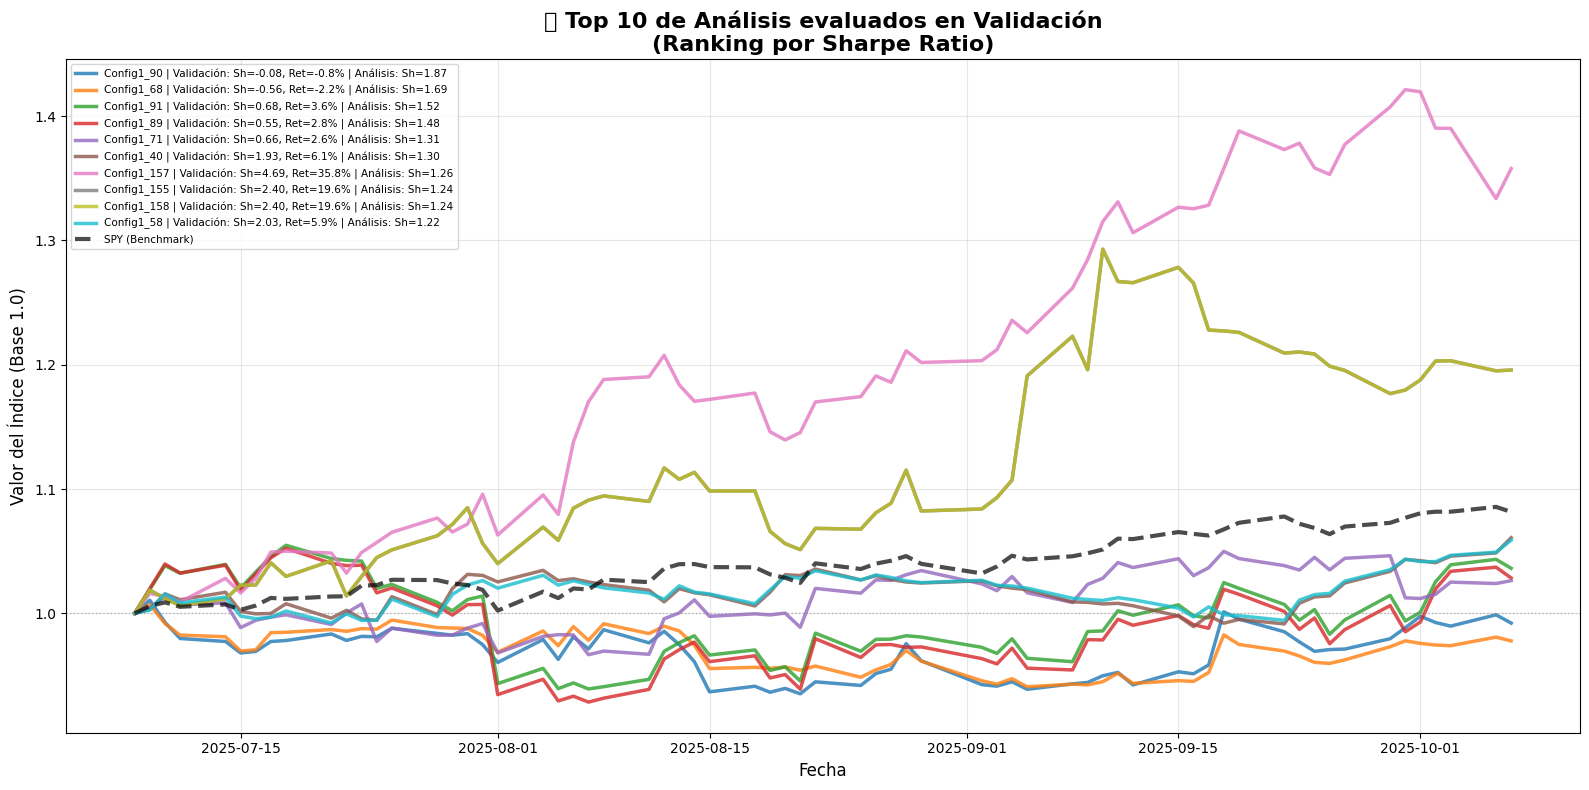

✅ Gráfica generada: Top 10 de Análisis en Validación


In [19]:
# =======================================================
# 📊 ANÁLISIS CRUZADO 1:
# Top 10 del Período de Análisis graficados con datos de VALIDACIÓN
# (¿Cómo se comportan los mejores in-sample en datos out-of-sample?)
# =======================================================

print("="*100)
print("🔄 ANÁLISIS CRUZADO 1: Top 10 de Análisis evaluados en Validación")
print("="*100)

# Guardar los top 10 del período de análisis
# Necesitamos recrear los índices del período de análisis primero
cluster_indices_analysis = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Crear summary_df del período de análisis
summary_data_analysis = []
for cluster_name, cluster_data in cluster_indices_analysis.items():
    summary_data_analysis.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'],
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df_analysis = pd.DataFrame(summary_data_analysis)
summary_df_analysis = summary_df_analysis.sort_values('Sharpe Ratio', ascending=False)

# Extraer los top 10 clusters del período de análisis
top_10_analysis = summary_df_analysis.head(10)['Cluster'].tolist()

print(f"\n📋 Top 10 clusters del período de ANÁLISIS:")
for i, cluster_name in enumerate(top_10_analysis, 1):
    sharpe_analysis = summary_df_analysis[summary_df_analysis['Cluster'] == cluster_name]['Sharpe Ratio'].values[0]
    ret_analysis = summary_df_analysis[summary_df_analysis['Cluster'] == cluster_name]['Retorno (%)'].values[0]
    print(f"   {i:2d}. {cluster_name}: Sharpe={sharpe_analysis:.2f}, Ret={ret_analysis:.1f}%")

# Graficar usando función estandarizada
plot_top_clusters_cross_period(
    top_clusters_list=top_10_analysis,
    all_clusters=all_clusters,
    target_data=validation_data,
    target_data_spy=SPY_validation,
    source_summary_df=summary_df_analysis,
    market_caps_dict=market_caps,
    source_period_name="Análisis",
    target_period_name="Validación",
    ranking_metric="Sharpe Ratio"
)


🔄 ANÁLISIS CRUZADO 2: Top 10 de Validación evaluados en Análisis
✅ Config1_4: 5 tickers, Sharpe=-0.33, Ret=-2.05%
✅ Config1_7: 5 tickers, Sharpe=-0.33, Ret=-2.05%
✅ Config1_10: 4 tickers, Sharpe=-0.51, Ret=-2.46%
✅ Config1_14: 4 tickers, Sharpe=-1.28, Ret=-5.76%
✅ Config1_15: 4 tickers, Sharpe=-0.51, Ret=-2.46%
✅ Config1_19: 4 tickers, Sharpe=-0.26, Ret=-1.78%
✅ Config1_22: 5 tickers, Sharpe=1.10, Ret=4.01%
✅ Config1_25: 6 tickers, Sharpe=-0.59, Ret=-2.74%
✅ Config1_29: 4 tickers, Sharpe=-1.28, Ret=-5.76%
✅ Config1_30: 4 tickers, Sharpe=-0.51, Ret=-2.46%
✅ Config1_34: 6 tickers, Sharpe=0.28, Ret=0.87%
✅ Config1_35: 5 tickers, Sharpe=1.40, Ret=4.59%
✅ Config1_37: 6 tickers, Sharpe=0.60, Ret=2.08%
✅ Config1_38: 7 tickers, Sharpe=2.46, Ret=7.06%
✅ Config1_39: 9 tickers, Sharpe=0.25, Ret=0.68%
✅ Config1_40: 4 tickers, Sharpe=1.93, Ret=6.09%
✅ Config1_41: 6 tickers, Sharpe=0.60, Ret=2.08%
✅ Config1_42: 4 tickers, Sharpe=2.16, Ret=8.85%
✅ Config1_43: 5 tickers, Sharpe=-1.79, Ret=-8.08%
✅ Co

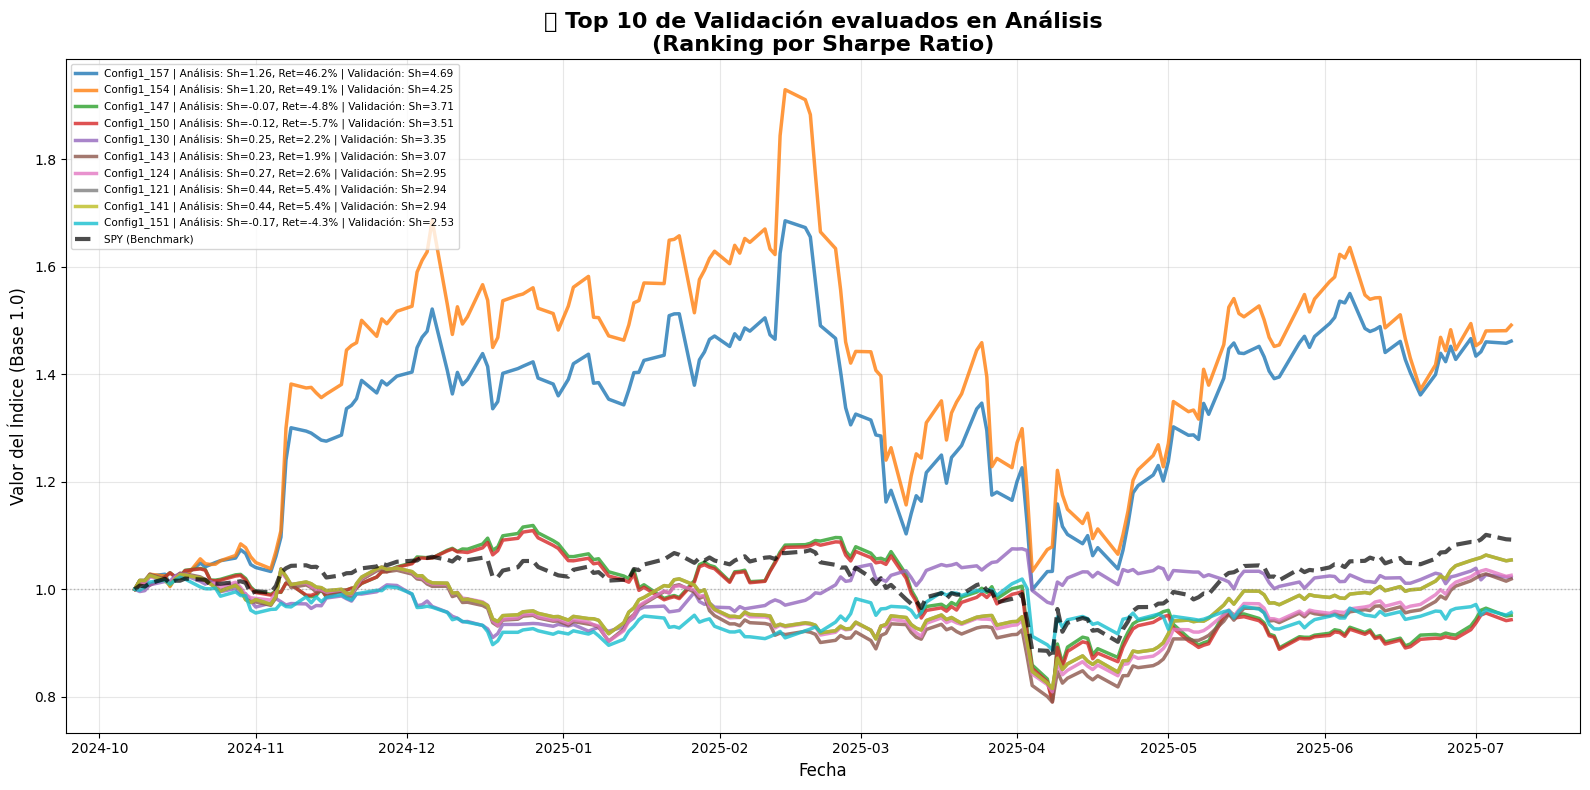

✅ Gráfica generada: Top 10 de Validación en Análisis


In [20]:
# =======================================================
# 📊 ANÁLISIS CRUZADO 2:
# Top 10 del Período de Validación graficados con datos de ANÁLISIS
# (¿Cómo se comportaron los mejores out-of-sample en datos in-sample?)
# =======================================================

print("\n" + "="*100)
print("🔄 ANÁLISIS CRUZADO 2: Top 10 de Validación evaluados en Análisis")
print("="*100)

# Recrear los índices del período de validación
cluster_indices_validation = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=validation_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Crear summary_df del período de validación
summary_data_validation = []
for cluster_name, cluster_data in cluster_indices_validation.items():
    index_series = cluster_data['index']
    summary_data_validation.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'],
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df_validation = pd.DataFrame(summary_data_validation)
summary_df_validation = summary_df_validation.sort_values('Sharpe Ratio', ascending=False)

# Extraer los top 10 clusters del período de validación
top_10_validation = summary_df_validation.head(10)['Cluster'].tolist()

print(f"\n📋 Top 10 clusters del período de VALIDACIÓN:")
for i, cluster_name in enumerate(top_10_validation, 1):
    sharpe_val = summary_df_validation[summary_df_validation['Cluster'] == cluster_name]['Sharpe Ratio'].values[0]
    ret_val = summary_df_validation[summary_df_validation['Cluster'] == cluster_name]['Retorno (%)'].values[0]
    print(f"   {i:2d}. {cluster_name}: Sharpe={sharpe_val:.2f}, Ret={ret_val:.1f}%")

# Graficar usando función estandarizada
plot_top_clusters_cross_period(
    top_clusters_list=top_10_validation,
    all_clusters=all_clusters,
    target_data=tickers_data,
    target_data_spy=SPY_analysis,
    source_summary_df=summary_df_validation,
    market_caps_dict=market_caps,
    source_period_name="Validación",
    target_period_name="Análisis",
    ranking_metric="Sharpe Ratio"
)

### Selección por Score Personalizado

⭐ SELECCIÓN POR SCORE PERSONALIZADO

📊 Pesos del Score:
   W1 (Retorno):      0.30
   W2 (Sharpe):       0.40
   W3 (Volatilidad):  0.15 (penalización)
   W4 (Max Drawdown): 0.15 (penalización)

   Fórmula: Score = 0.3*Retorno + 0.4*Sharpe - 0.15*Volatilidad - 0.15*|Drawdown|
✅ Config1_4: 5 tickers, Sharpe=0.85, Ret=15.66%
✅ Config1_7: 5 tickers, Sharpe=0.85, Ret=15.66%
✅ Config1_10: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_14: 4 tickers, Sharpe=0.48, Ret=5.48%
✅ Config1_15: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_19: 4 tickers, Sharpe=0.96, Ret=18.49%
✅ Config1_22: 5 tickers, Sharpe=0.84, Ret=14.23%
✅ Config1_25: 6 tickers, Sharpe=0.60, Ret=9.06%
✅ Config1_29: 4 tickers, Sharpe=0.48, Ret=5.48%
✅ Config1_30: 4 tickers, Sharpe=0.65, Ret=10.12%
✅ Config1_34: 6 tickers, Sharpe=0.18, Ret=1.07%
✅ Config1_35: 5 tickers, Sharpe=-0.10, Ret=-2.26%
✅ Config1_37: 6 tickers, Sharpe=0.31, Ret=3.52%
✅ Config1_38: 7 tickers, Sharpe=1.12, Ret=12.47%
✅ Config1_39: 9 tickers, Sharpe=-0.03, Ret=

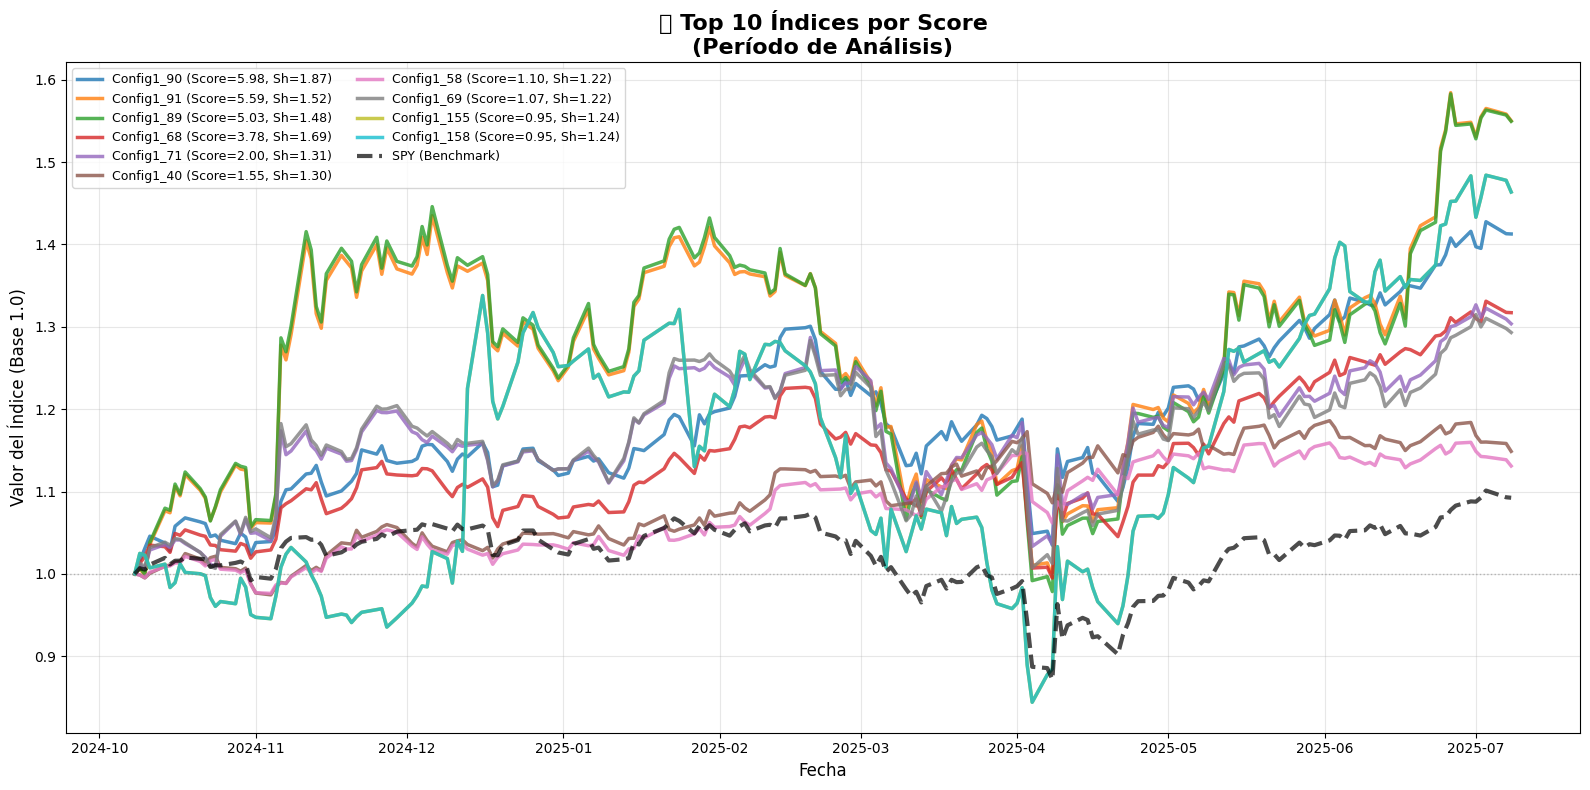

✅ Gráfica generada


In [21]:
# =======================================================
# 📊 SELECCIÓN POR SCORE PERSONALIZADO - PERÍODO DE ANÁLISIS
# Score = W1*Retorno + W2*Sharpe - W3*Volatilidad - W4*Drawdown
# =======================================================

print("="*100)
print("⭐ SELECCIÓN POR SCORE PERSONALIZADO")
print("="*100)

# ✅ DEFINIR PESOS (Ajusta estos valores según tus preferencias)
W1 = 0.3  # Peso para Retorno
W2 = 0.4  # Peso para Sharpe Ratio
W3 = 0.15  # Peso para Volatilidad (penalización)
W4 = 0.15  # Peso para Max Drawdown (penalización)

print(f"\n📊 Pesos del Score:")
print(f"   W1 (Retorno):      {W1:.2f}")
print(f"   W2 (Sharpe):       {W2:.2f}")
print(f"   W3 (Volatilidad):  {W3:.2f} (penalización)")
print(f"   W4 (Max Drawdown): {W4:.2f} (penalización)")
print(f"\n   Fórmula: Score = {W1}*Retorno + {W2}*Sharpe - {W3}*Volatilidad - {W4}*|Drawdown|")

# Recrear índices del período de análisis
cluster_indices_analysis_score = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Crear DataFrame con métricas y calcular Score
summary_data_score = []
for cluster_name, cluster_data in cluster_indices_analysis_score.items():
    retorno = cluster_data['metrics']['retorno_total']
    sharpe = cluster_data['metrics']['sharpe_ratio']
    volatilidad = cluster_data['metrics']['volatilidad']
    drawdown = abs(cluster_data['metrics']['max_drawdown'])  # Valor absoluto para penalización
    
    # Calcular Score personalizado
    score = W1 * retorno + W2 * sharpe - W3 * volatilidad - W4 * drawdown
    
    # Agregar score a las métricas del cluster
    cluster_data['metrics']['score'] = score
    
    summary_data_score.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Retorno (%)': retorno,
        'Sharpe Ratio': sharpe,
        'Volatilidad (%)': volatilidad,
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'],
        'Score': score
    })

summary_df_score = pd.DataFrame(summary_data_score)
summary_df_score = summary_df_score.sort_values('Score', ascending=False)

print("\n📊 TOP 10 ÍNDICES POR SCORE PERSONALIZADO (Período de Análisis):")
print(summary_df_score.head(10).to_string(index=False))

print("\n\n📊 ESTADÍSTICAS DEL SCORE:")
print(f"   ⭐ Score promedio: {summary_df_score['Score'].mean():.2f}")
print(f"   📈 Score máximo: {summary_df_score['Score'].max():.2f}")
print(f"   📉 Score mínimo: {summary_df_score['Score'].min():.2f}")

# Extraer top 10 por Score
top_10_by_score = summary_df_score.head(10)['Cluster'].tolist()

print(f"\n🏆 Top 10 clusters por Score personalizado:")
for i, cluster_name in enumerate(top_10_by_score, 1):
    row = summary_df_score[summary_df_score['Cluster'] == cluster_name].iloc[0]
    print(f"   {i:2d}. {cluster_name}: Score={row['Score']:.2f} | Ret={row['Retorno (%)']:.1f}% | Sh={row['Sharpe Ratio']:.2f}")

# Graficar usando función estandarizada
plot_top_clusters_same_period(
    cluster_indices_dict=cluster_indices_analysis_score,
    top_clusters_list=top_10_by_score,
    data_for_spy=SPY_analysis,
    period_name="Análisis",
    ranking_metric="Score"
)


🔄 Top 10 de Análisis evaluados en Validación...


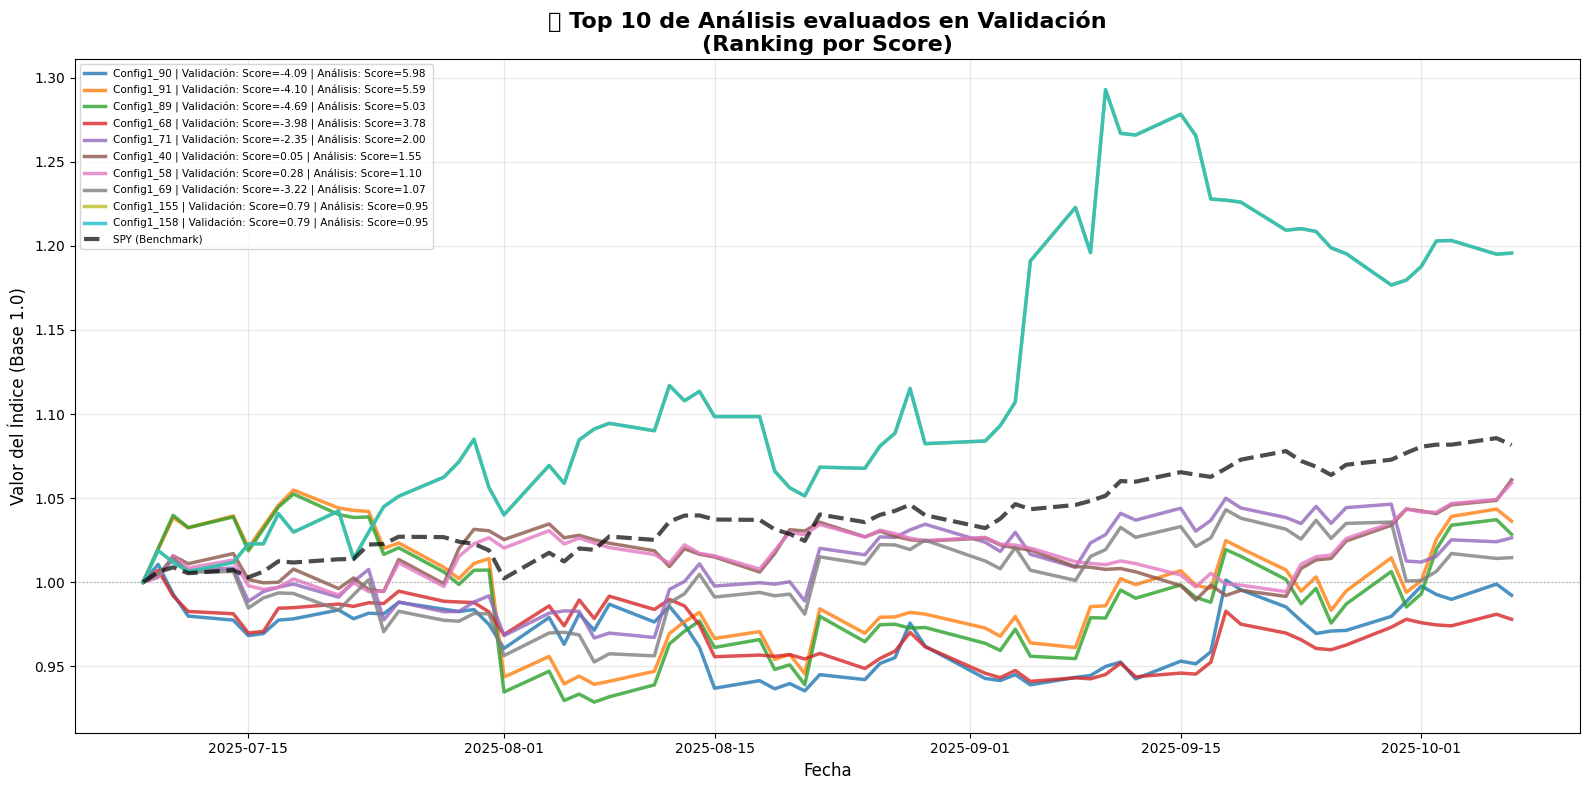

✅ Gráfica generada: Top 10 de Análisis en Validación


In [22]:
# =======================================================
# 📈 GRÁFICA: Top 10 por Score (de Análisis) evaluados en VALIDACIÓN
# (¿Los mejores por Score in-sample mantienen su performance out-of-sample?)
# =======================================================

# Graficar usando función estandarizada con validación cruzada
plot_top_clusters_cross_period(
    top_clusters_list=top_10_by_score,
    all_clusters=all_clusters,
    target_data=validation_data,
    target_data_spy=SPY_validation,
    source_summary_df=summary_df_score,
    market_caps_dict=market_caps,
    source_period_name="Análisis",
    target_period_name="Validación",
    ranking_metric="Score",
    weights_dict={'W1': W1, 'W2': W2, 'W3': W3, 'W4': W4}
)

### Analiza cluster específico

In [23]:
def analizar_cluster(cluster_name, all_clusters, tickers_data, validation_data, 
                     market_caps, ticker_info_db):
    """
    Muestra estadísticas detalladas de un cluster específico.
    
    Parámetros:
    -----------
    cluster_name : str
        Nombre del cluster a analizar (ej: "Config1_1")
    all_clusters : dict
        Diccionario con información de todos los clusters
    tickers_data : pd.DataFrame
        Datos del período de análisis
    validation_data : pd.DataFrame
        Datos del período de validación
    market_caps : dict
        Diccionario con capitalizaciones de mercado
    ticker_info_db : dict
        Diccionario con información fundamental de tickers
    """
    
    if cluster_name not in all_clusters:
        print(f"❌ El cluster '{cluster_name}' no existe.")
        print(f"   Clusters disponibles: {list(all_clusters.keys())}")
        return
    
    # Obtener información del cluster
    cluster_info = all_clusters[cluster_name]
    cluster_tickers = cluster_info['tickers']
    cluster_type = cluster_info['type']
    
    print("=" * 100)
    print(f"📊 ANÁLISIS DETALLADO DEL CLUSTER: {cluster_name}")
    print("=" * 100)
    
    # Información básica
    print(f"\n📋 INFORMACIÓN GENERAL:")
    print(f"   Tipo de análisis: {cluster_type}")
    print(f"   Número de tickers: {len(cluster_tickers)}")
    print(f"   Tickers: {', '.join(cluster_tickers)}")
    
    # Capitalización de mercado total
    total_market_cap = sum([market_caps.get(t, 0) for t in cluster_tickers if t in market_caps])
    print(f"\n💰 CAPITALIZACIÓN DE MERCADO:")
    print(f"   Total del cluster: ${total_market_cap/1e9:.2f}B")
    print(f"   Promedio por ticker: ${(total_market_cap/len(cluster_tickers))/1e9:.2f}B")
    
    # Distribución por sector
    print(f"\n🏢 DISTRIBUCIÓN POR SECTOR:")
    sectors = {}
    for ticker in cluster_tickers:
        sector = ticker_info_db.get(ticker, {}).get('sector', 'Unknown')
        sectors[sector] = sectors.get(sector, 0) + 1
    
    for sector, count in sorted(sectors.items(), key=lambda x: x[1], reverse=True):
        pct = (count / len(cluster_tickers)) * 100
        print(f"   {sector:30s}: {count:2d} empresas ({pct:5.1f}%)")
    
    # Pesos en el índice (por market cap)
    print(f"\n⚖️  PESOS EN EL ÍNDICE (Top 10 por Market Cap):")
    valid_tickers = [t for t in cluster_tickers if t in market_caps]
    ticker_weights = [(t, market_caps[t] / total_market_cap * 100) for t in valid_tickers]
    ticker_weights.sort(key=lambda x: x[1], reverse=True)
    
    for i, (ticker, weight) in enumerate(ticker_weights[:10], 1):
        sector = ticker_info_db.get(ticker, {}).get('sector', 'Unknown')
        print(f"   {i:2d}. {ticker:5s}: {weight:5.2f}% | {sector}")
    
    # Métricas en período de ANÁLISIS
    print(f"\n📈 MÉTRICAS EN PERÍODO DE ANÁLISIS:")
    index_analysis, weights_analysis = create_market_cap_weighted_index(
        cluster_tickers, tickers_data, market_caps, start_value=1
    )
    
    if index_analysis is not None:
        returns_analysis = index_analysis.pct_change().dropna()
        ret_analysis = (index_analysis.iloc[-1] / index_analysis.iloc[0] - 1) * 100
        vol_analysis = returns_analysis.std() * np.sqrt(252) * 100
        sharpe_analysis = (returns_analysis.mean() / returns_analysis.std() * np.sqrt(252)) if returns_analysis.std() > 0 else 0
        dd_analysis = ((index_analysis / index_analysis.cummax()) - 1).min() * 100
        
        print(f"   📊 Retorno Total:     {ret_analysis:6.2f}%")
        print(f"   📊 Volatilidad:       {vol_analysis:6.2f}%")
        print(f"   ⭐ Sharpe Ratio:      {sharpe_analysis:6.2f}")
        print(f"   📉 Max Drawdown:      {dd_analysis:6.2f}%")
        print(f"   📈 Valor Inicial:     {index_analysis.iloc[0]:.4f}")
        print(f"   📈 Valor Final:       {index_analysis.iloc[-1]:.4f}")
    
    # Métricas en período de VALIDACIÓN
    print(f"\n🔄 MÉTRICAS EN PERÍODO DE VALIDACIÓN:")
    index_validation, weights_validation = create_market_cap_weighted_index(
        cluster_tickers, validation_data, market_caps, start_value=1
    )
    
    if index_validation is not None:
        returns_validation = index_validation.pct_change().dropna()
        ret_validation = (index_validation.iloc[-1] / index_validation.iloc[0] - 1) * 100
        vol_validation = returns_validation.std() * np.sqrt(252) * 100
        sharpe_validation = (returns_validation.mean() / returns_validation.std() * np.sqrt(252)) if returns_validation.std() > 0 else 0
        dd_validation = ((index_validation / index_validation.cummax()) - 1).min() * 100
        
        print(f"   📊 Retorno Total:     {ret_validation:6.2f}%")
        print(f"   📊 Volatilidad:       {vol_validation:6.2f}%")
        print(f"   ⭐ Sharpe Ratio:      {sharpe_validation:6.2f}")
        print(f"   📉 Max Drawdown:      {dd_validation:6.2f}%")
        print(f"   📈 Valor Inicial:     {index_validation.iloc[0]:.4f}")
        print(f"   📈 Valor Final:       {index_validation.iloc[-1]:.4f}")
    
    # Comparación entre períodos
    if index_analysis is not None and index_validation is not None:
        print(f"\n🔍 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:")
        print(f"   Diferencia Retorno:  {ret_validation - ret_analysis:+6.2f}%")
        print(f"   Diferencia Sharpe:   {sharpe_validation - sharpe_analysis:+6.2f}")
        print(f"   Diferencia Vol:      {vol_validation - vol_analysis:+6.2f}%")
    
    # Información detallada de cada ticker
    print(f"\n📋 DETALLES DE CADA TICKER:")
    print(f"{'Ticker':<8} {'Empresa':<40} {'Sector':<25} {'Market Cap':<12} {'Peso':<8}")
    print("-" * 100)
    
    for ticker in cluster_tickers:
        info = ticker_info_db.get(ticker, {})
        empresa = info.get('full_name', ticker)[:38]
        sector = info.get('sector', 'Unknown')[:23]
        mcap = market_caps.get(ticker, 0)
        mcap_str = f"${mcap/1e9:.2f}B" if mcap > 0 else "N/A"
        peso = (market_caps.get(ticker, 0) / total_market_cap * 100) if total_market_cap > 0 else 0
        peso_str = f"{peso:.2f}%"
        
        print(f"{ticker:<8} {empresa:<40} {sector:<25} {mcap_str:<12} {peso_str:<8}")
    
    # Gráficas comparativas con S&P 500 (usando variables globales SPY_analysis y SPY_validation)
    print(f"\n📊 GRÁFICAS COMPARATIVAS CON S&P 500:")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfica 1: Período de Análisis
    if index_analysis is not None:
        ax1.plot(index_analysis, linewidth=2.5, color='#2E86AB', label=f'{cluster_name}', alpha=0.9)
        
        # Agregar SPY usando variable global SPY_analysis
        try:
            spy_data_analysis = SPY_analysis['SPY'].dropna()
            spy_norm_analysis = spy_data_analysis / spy_data_analysis.iloc[0]
            ax1.plot(spy_norm_analysis, linewidth=2.5, linestyle='--', 
                    color='#E63946', label='S&P 500 (SPY)', alpha=0.8)
        except (NameError, KeyError):
            print("⚠️  SPY_analysis no disponible para gráfica de análisis")
        
        ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        ax1.set_title(f'Período de Análisis\n{cluster_name} vs S&P 500', 
                     fontsize=12, fontweight='bold')
        ax1.set_xlabel('Fecha', fontsize=10)
        ax1.set_ylabel('Valor Normalizado (Base 1.0)', fontsize=10)
        ax1.legend(fontsize=9, loc='best')
        ax1.grid(True, alpha=0.3)
    
    # Gráfica 2: Período de Validación
    if index_validation is not None:
        ax2.plot(index_validation, linewidth=2.5, color='#2E86AB', label=f'{cluster_name}', alpha=0.9)
        
        # Agregar SPY usando variable global SPY_validation
        try:
            spy_data_validation = SPY_validation['SPY'].dropna()
            spy_norm_validation = spy_data_validation / spy_data_validation.iloc[0]
            ax2.plot(spy_norm_validation, linewidth=2.5, linestyle='--', 
                    color='#E63946', label='S&P 500 (SPY)', alpha=0.8)
        except (NameError, KeyError):
            print("⚠️  SPY_validation no disponible para gráfica de validación")
        
        ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        ax2.set_title(f'Período de Validación\n{cluster_name} vs S&P 500', 
                     fontsize=12, fontweight='bold')
        ax2.set_xlabel('Fecha', fontsize=10)
        ax2.set_ylabel('Valor Normalizado (Base 1.0)', fontsize=10)
        ax2.legend(fontsize=9, loc='best')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Gráfica adicional: Tickers individuales con datos combinados
    print(f"\n📊 GRÁFICA: DESEMPEÑO INDIVIDUAL DE TODOS LOS TICKERS DEL CLUSTER")
    
    # Combinar datos de ambos períodos
    all_tickers_data_combined = pd.concat([tickers_data, validation_data])
    
    # Filtrar solo los tickers del cluster
    cluster_data_combined = all_tickers_data_combined[cluster_tickers].dropna(how='all')
    
    # Normalizar cada ticker a base 1.0 desde su primer valor
    cluster_data_normalized = cluster_data_combined.copy()
    for ticker in cluster_tickers:
        if ticker in cluster_data_normalized.columns:
            first_valid = cluster_data_normalized[ticker].first_valid_index()
            if first_valid is not None:
                cluster_data_normalized[ticker] = cluster_data_normalized[ticker] / cluster_data_normalized.loc[first_valid, ticker]
    
    # Crear gráfica
    fig, ax = plt.subplots(figsize=(18, 8))
    
    # Graficar cada ticker del cluster
    colors = plt.cm.tab20(np.linspace(0, 1, len(cluster_tickers)))
    for i, ticker in enumerate(cluster_tickers):
        if ticker in cluster_data_normalized.columns:
            ax.plot(cluster_data_normalized[ticker], label=ticker, 
                   linewidth=1.5, alpha=0.7, color=colors[i])
    
    # Línea vertical separando períodos
    separation_date = tickers_data.index[-1]
    ax.axvline(x=separation_date, color='red', linestyle='--', linewidth=2.5, 
              label='Separación Análisis/Validación', alpha=0.8)
    
    # Línea horizontal de referencia
    ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Configuración de la gráfica
    ax.set_title(f'Desempeño Individual de Tickers en {cluster_name}\n(Normalizado a Base 1.0)', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Valor Normalizado (Base 1.0)', fontsize=11)
    ax.legend(fontsize=8, loc='upper left', ncol=3, bbox_to_anchor=(0, -0.1))
    ax.grid(True, alpha=0.3)
    
    # Añadir etiquetas de período
    mid_analysis = tickers_data.index[len(tickers_data)//2]
    mid_validation = validation_data.index[len(validation_data)//2]
    ax.text(mid_analysis, ax.get_ylim()[1]*0.95, 'Período de Análisis', 
           fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    ax.text(mid_validation, ax.get_ylim()[1]*0.95, 'Período de Validación', 
           fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 100)

📊 ANÁLISIS DETALLADO DEL CLUSTER: Config1_158

📋 INFORMACIÓN GENERAL:
   Tipo de análisis: Sharpe Ratio
   Número de tickers: 7
   Tickers: AVB, AVGO, AVY, AWK, AXON, AXP, AZO

💰 CAPITALIZACIÓN DE MERCADO:
   Total del cluster: $2235.26B
   Promedio por ticker: $319.32B

🏢 DISTRIBUCIÓN POR SECTOR:
   Consumer Cyclical             :  2 empresas ( 28.6%)
   Real Estate                   :  1 empresas ( 14.3%)
   Technology                    :  1 empresas ( 14.3%)
   Utilities                     :  1 empresas ( 14.3%)
   Industrials                   :  1 empresas ( 14.3%)
   Financial Services            :  1 empresas ( 14.3%)

⚖️  PESOS EN EL ÍNDICE (Top 10 por Market Cap):
    1. AVGO : 80.49% | Technology
    2. AXP  : 11.11% | Financial Services
    3. AZO  :  2.81% | Consumer Cyclical
    4. AXON :  2.67% | Industrials
    5. AWK  :  1.15% | Utilities
    6. AVB  :  1.14% | Real Estate
    7. AVY  :  0.63% | Consumer Cyclical

📈 MÉTRICAS EN PERÍODO DE ANÁLISIS:
   📊 Retorno Total:

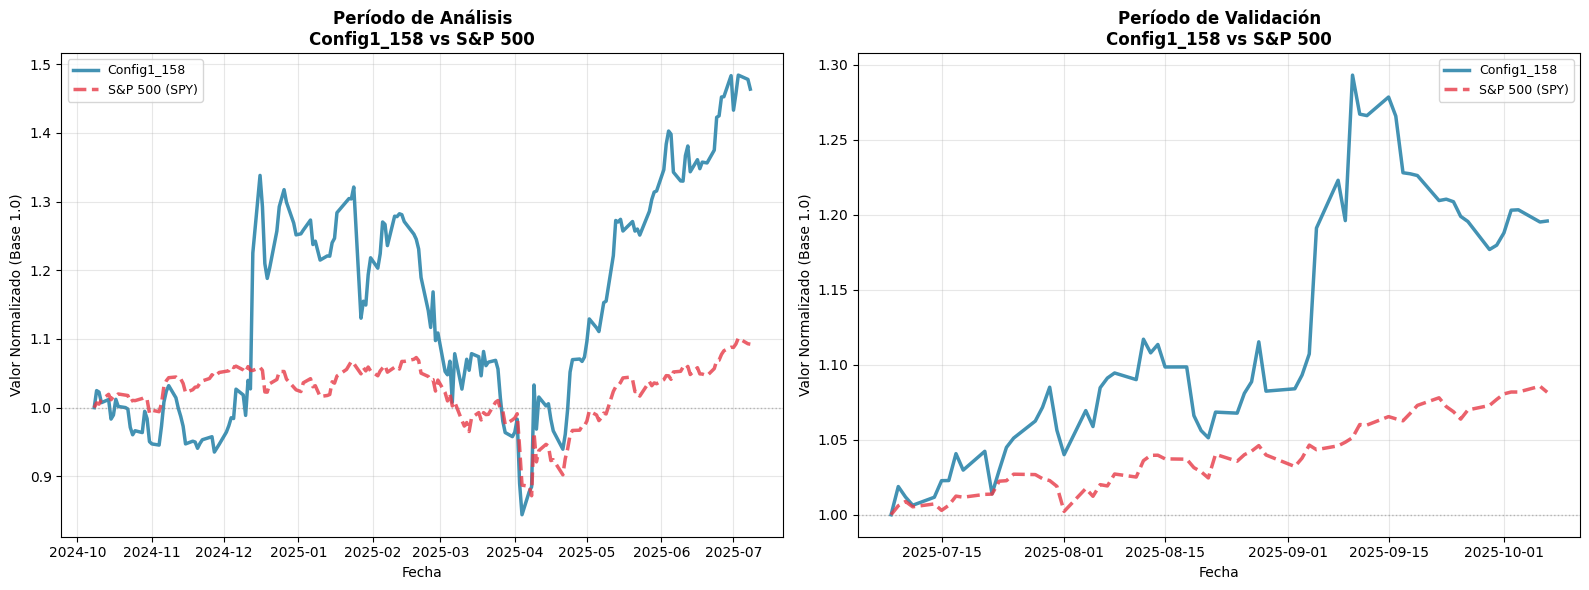


📊 GRÁFICA: DESEMPEÑO INDIVIDUAL DE TODOS LOS TICKERS DEL CLUSTER


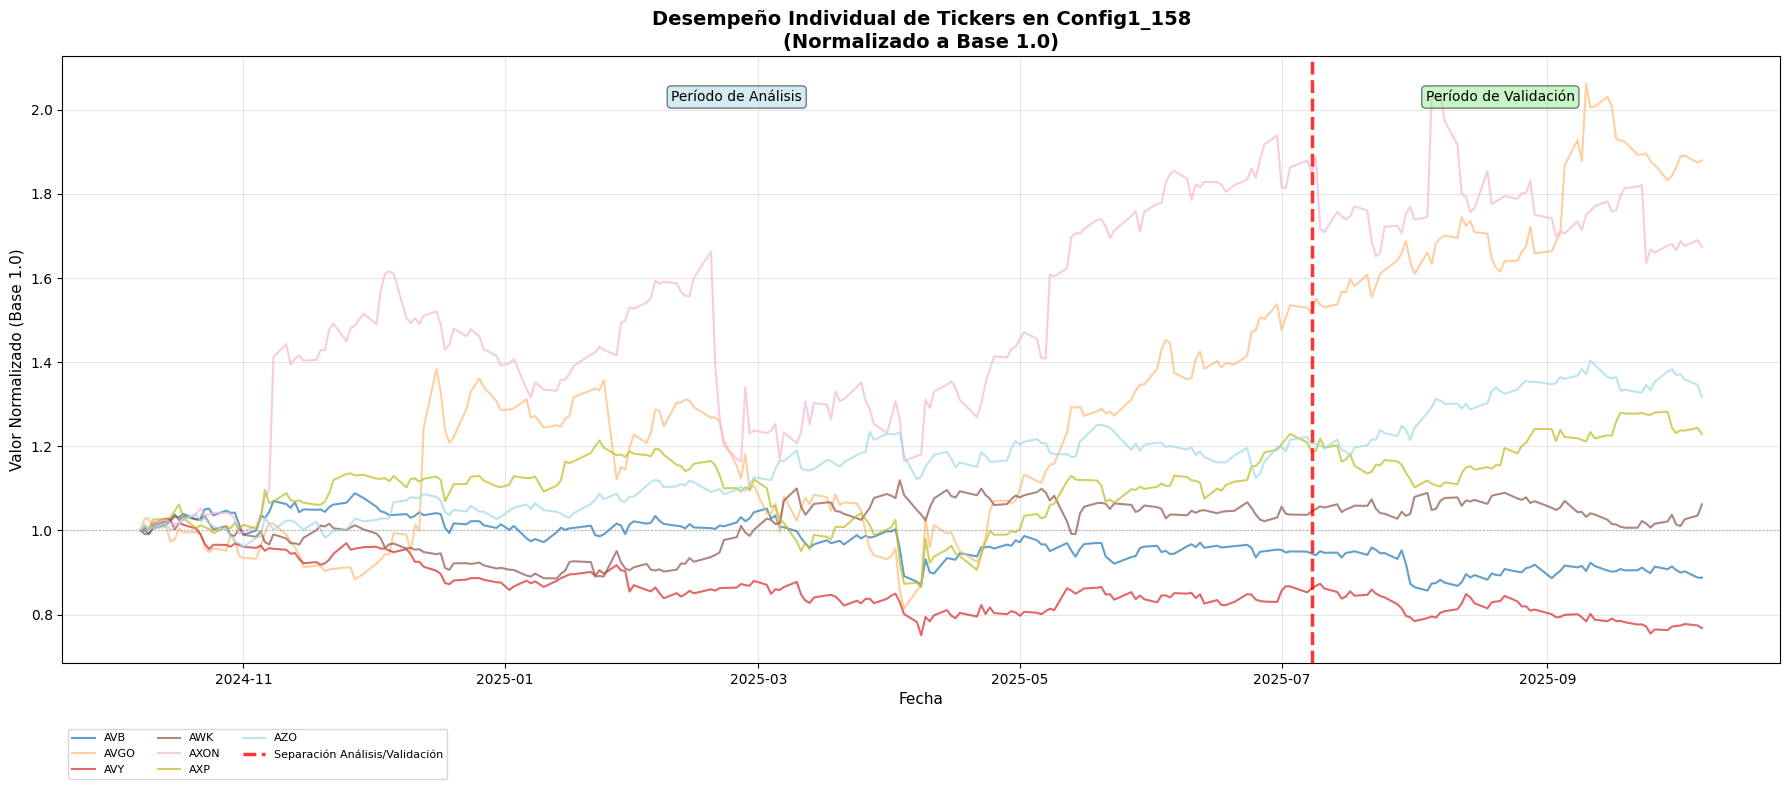

In [24]:
# Analizar un cluster específico
analizar_cluster(
    cluster_name="Config1_158",
    all_clusters=all_clusters,
    tickers_data=tickers_data,
    validation_data=validation_data,
    market_caps=market_caps,
    ticker_info_db=ticker_info_db
)